Now import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print('Libraries imported successfully')

Libraries imported successfully


Load the dataset

In [3]:
df = pd.read_csv('cleaned_global_ecommerce_data.csv')
print('datasert loaded successfully')

datasert loaded successfully


In [4]:
df.head()

,Transaction_ID,Date,Customer_ID,Customer_Age,Gender,Location,Product_Category,Product_Name,Unit_Price,Quantity,Discount_Applied,Total_Revenue,Payment_Method,Delivery_Time_Days,Customer_Rating
0,TXN1000,01-01-2023,CUST_4764,39,Male,Pakistan,Apparel,Cotton T-Shirt,89.50,3,0.04,257.76,PayPal,8,3.3
1,TXN1001,01-01-2023,CUST_20831,33,Male,Germany,Electronics,4K Smart TV,1129.50,3,0.05,3219.07,Credit Card,9,3.8
2,TXN1002,01-01-2023,CUST_15374,41,Non-binary,Germany,Home & Kitchen,Air Fryer,195.79,2,0.13,340.67,Credit Card,14,1.5
3,TXN1003,01-01-2023,CUST_17541,50,Non-binary,UAE,Electronics,Gaming Laptop,1153.43,1,0.10,1038.09,Bank Transfer,11,1.6
4,TXN1004,01-01-2023,CUST_14124,32,Male,UAE,Apparel,Formal Shirt,146.54,2,0.08,269.63,Credit Card,6,4.5


In [5]:
print("Number of rows and columns:")
print(df.shape)

Number of rows and columns:
(50000, 15)


In [6]:
print("data types:")
print(df.dtypes)

data types:
Transaction_ID            str
Date                      str
Customer_ID               str
Customer_Age            int64
Gender                    str
Location                  str
Product_Category          str
Product_Name              str
Unit_Price            float64
Quantity                int64
Discount_Applied      float64
Total_Revenue         float64
Payment_Method            str
Delivery_Time_Days      int64
Customer_Rating       float64
dtype: object


In [7]:
print("missing values:")
print(df.isnull().sum())

missing values:
Transaction_ID        0
Date                  0
Customer_ID           0
Customer_Age          0
Gender                0
Location              0
Product_Category      0
Product_Name          0
Unit_Price            0
Quantity              0
Discount_Applied      0
Total_Revenue         0
Payment_Method        0
Delivery_Time_Days    0
Customer_Rating       0
dtype: int64


Descriptive statistics

In [8]:
df.describe()

,Customer_Age,Unit_Price,Quantity,Discount_Applied,Total_Revenue,Delivery_Time_Days,Customer_Rating
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,34.703360,300.429862,2.483060,0.12261,642.526729,7.994300,3.327486
std,9.566322,389.478977,1.151338,0.08197,946.093846,4.321143,1.095440
min,18.000000,5.000000,1.000000,0.00000,4.670000,1.000000,1.000000
25%,28.000000,60.230000,2.000000,0.06000,107.980000,4.000000,2.500000
50%,35.000000,123.045000,2.000000,0.11000,244.275000,8.000000,3.500000
75%,41.000000,296.780000,3.000000,0.18000,665.777500,12.000000,4.200000
max,70.000000,1499.990000,5.000000,0.30000,6373.340000,15.000000,5.000000


Time Series Analysis


monthlySales Trend

fristly,convert the data collumn to datetime,caluculate monthly sales,convert the period
to timestamp for plotting,now plot monthly sales trend.


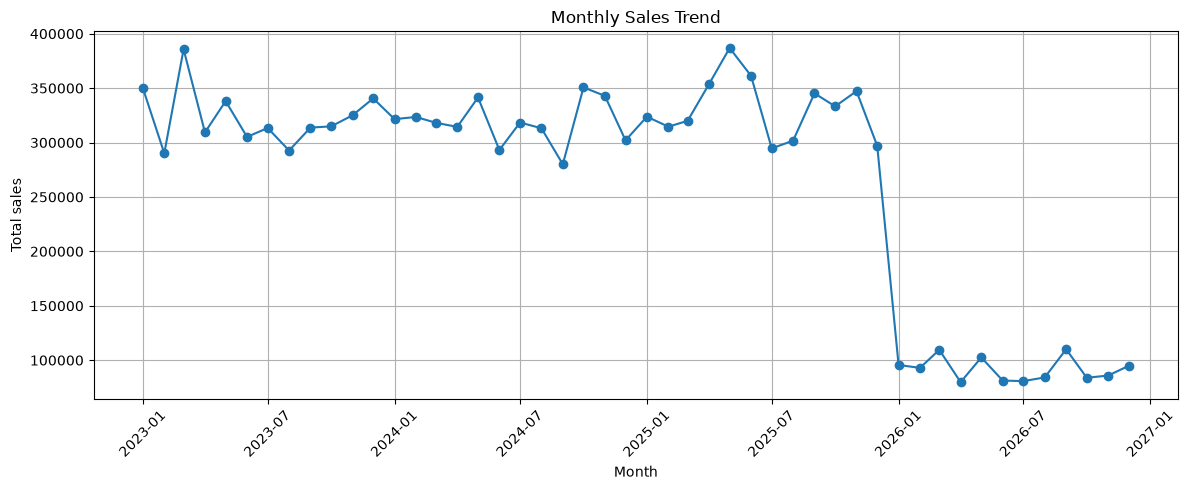

In [9]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total_Revenue'].sum()
monthly_sales.index=monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values,marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


observation:  Here,from  the above table content use the Monthly Sales Trend use the normal months during the significant peak indicating the higest to lowest sales.

Quaaterly Sales trend

firstly caclucate quaterly sales andconvert period totimestamp,plot quatrly sales trend.

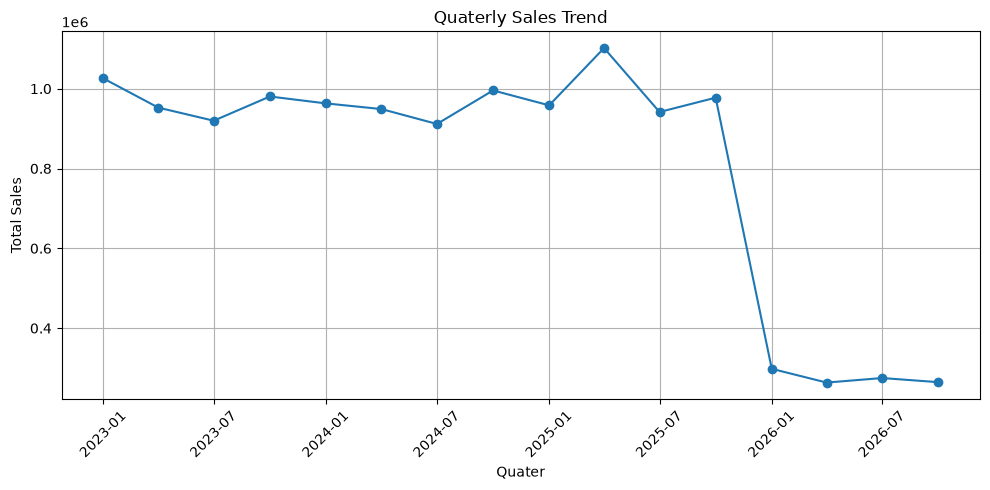

In [10]:
quaterly_Sales = df.groupby(df['Date'].dt.to_period('Q'))['Total_Revenue'].sum()
quaterly_Sales.index = quaterly_Sales.index.to_timestamp()
plt.figure(figsize=(10,5))
plt.plot(quaterly_Sales.index,quaterly_Sales.values,marker='o')
plt.title('Quaterly Sales Trend')
plt.xlabel('Quater')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


observation: the chart shows the sales wer generally stable for most of Quaterly.
Quater 2023year to 2024,2025 was major increse each years but 2025,2026 decresed sales values recorded.
2025 year was improve but last year was decresed

Customer Demographic Analyis

Customer Age Groups

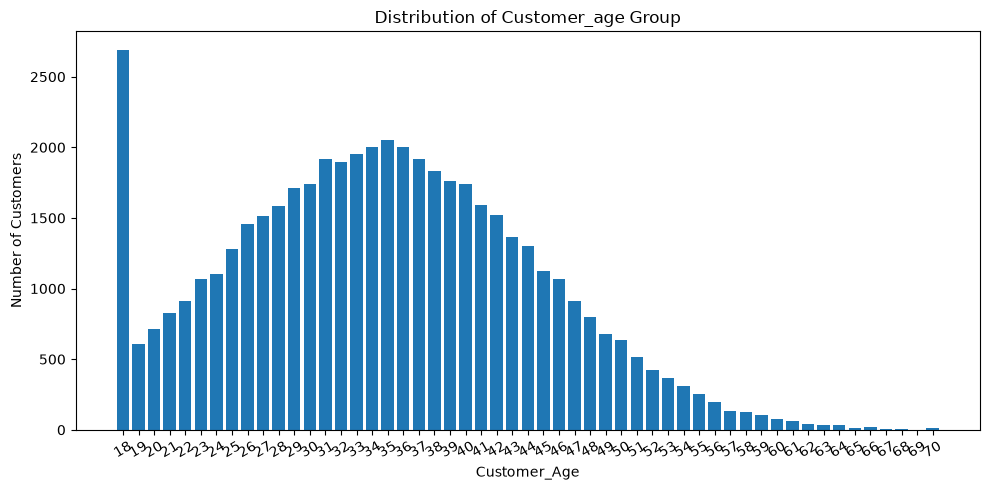

In [11]:
bins = [0,18,25,35,45,55,65,100]
labels = ['Below 18','18-25','26-35','36-45','46-55','56-65','Above 65']
df['customer_age'] = pd.cut(df['Customer_Age'],bins=bins,labels=labels,include_lowest=True)
customer_age_counts = df['Customer_Age'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(customer_age_counts.index.astype(str),customer_age_counts.values)
plt.title('Distribution of Customer_age Group')
plt.xlabel('Customer_Age')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


observation: from the above  chart,we can observe use number value form highest around the age 34,35,36 some of increase and decreases as age. 

Gender Breakdown

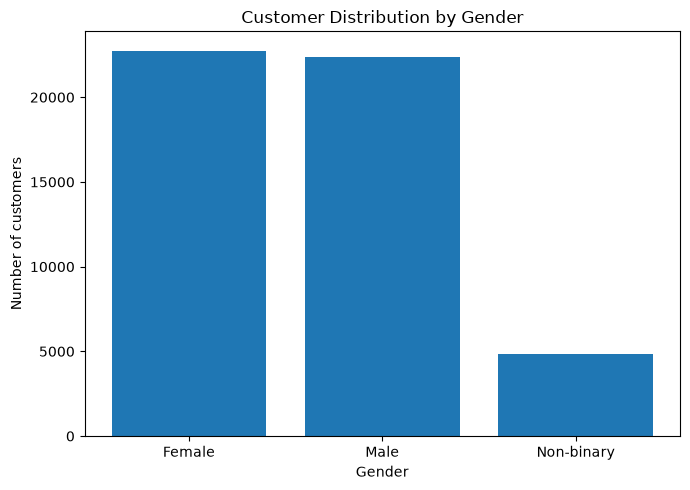

In [12]:
Gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(7,5))
plt.bar(Gender_counts.index,Gender_counts.values)
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

observation: from the above distribution with observe female, male,non-binary number of customer dataset. in this information helps us to understand the demograph of customers

Product Analysis

Note:the Dataset which i have considered doesn't contain the product name column.it only product
categeory.instead,i can analyze the best selling product Categories on quantity sold.

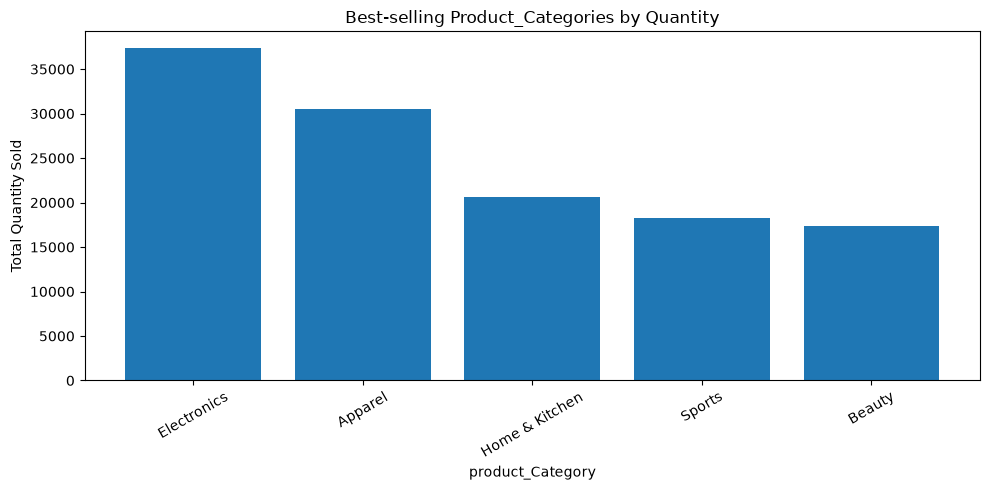

In [13]:
category_Quantity = (df.groupby('Product_Category')['Quantity'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
plt.bar(category_Quantity.index,category_Quantity.values)
plt.title('Best-selling Product_Categories by Quantity')  
plt.xlabel('product_Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()                                 

observatuion: above the chart we can observe the comparision between from product catagories uantity for  strongest things sold.the higst  quantity product selling category. define customer buying diffrent product categories

Revenue by product Category

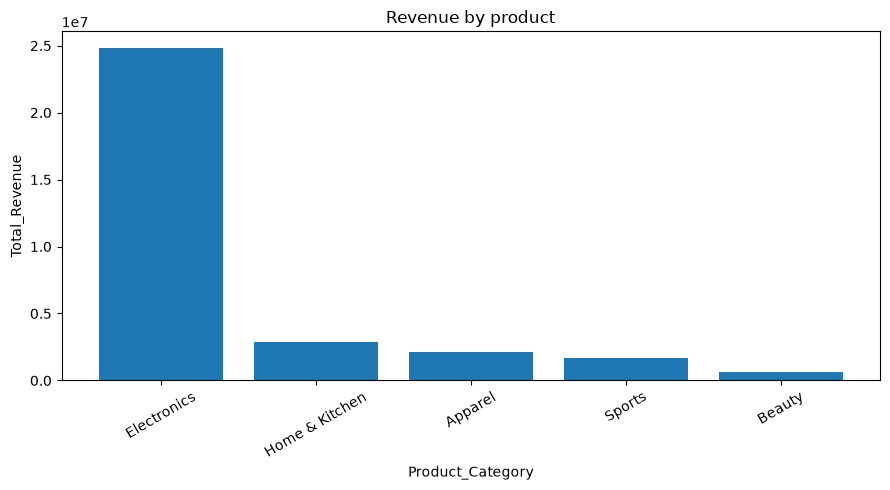

In [14]:
Product_Revenue = (df.groupby('Product_Category')['Total_Revenue'].sum().sort_values(ascending=False))
plt.figure(figsize=(9,5))
plt.bar(Product_Revenue.index,Product_Revenue.values)
plt.title('Revenue by product')
plt.xlabel('Product_Category')
plt.ylabel('Total_Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

observation: above the chart was revenue product observe that the Total Revenue by each product category. will be compairing revenue hepls from the most ofimportant areas of the business.

Corrwlation Heatmap

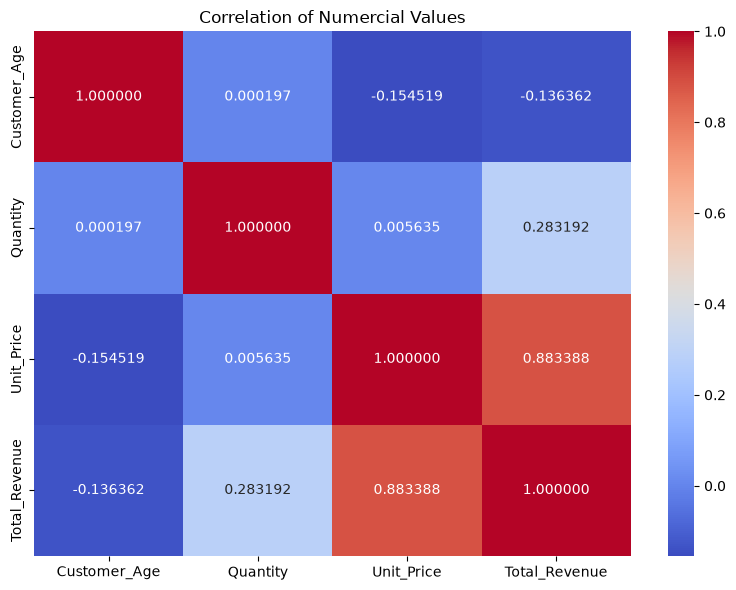

In [15]:
numercial_columns = ['Customer_Age','Quantity','Unit_Price','Total_Revenue']
correlation_matrix = df[numercial_columns].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='2f')
plt.title('Correlation of Numercial Values')
plt.tight_layout()
plt.show()


observation: the heatmap shows the correlation relationship between numercial varibles.this is the +1 close to positive relationship. some of witch are close to -1 indicated negative relationship.0 indicate aweak of relation ship

Aditional Visualization

Spending by Age group

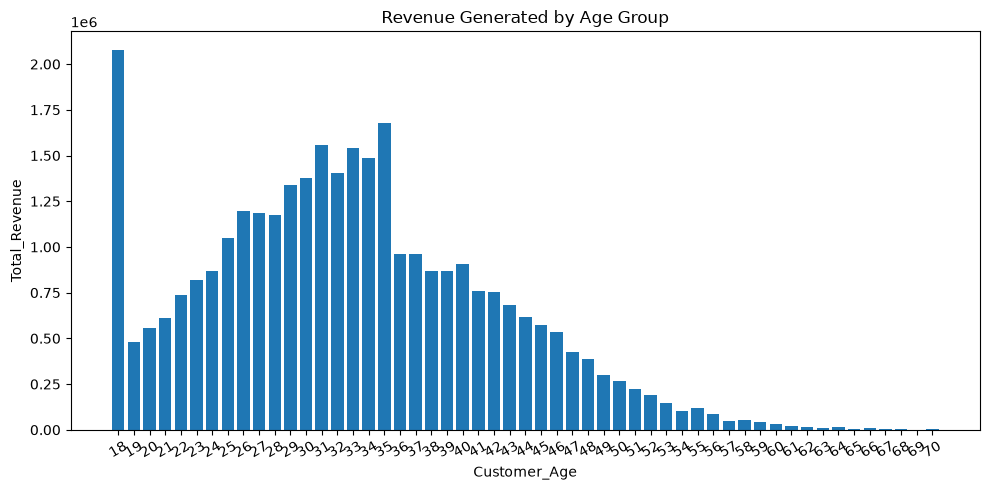

In [16]:
Age_Revenue = (df.groupby('Customer_Age',observed=True)['Total_Revenue'].sum())
plt.figure(figsize=(10,5))
plt.bar(Age_Revenue.index.astype(str),Age_Revenue.values)
plt.title('Revenue Generated by Age Group')
plt.xlabel('Customer_Age')
plt.ylabel('Total_Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

observation: total revenue wasprovide aditional information  customer behaviour.this customer segments with a contribution.

Core Revenue drivers(age 26-35):  define the age was 18 anomaly, revenue rises through the late 20s and peak around ages 31 to35
use data-driven marketing and product strategies.

conclusion: the exploratory Data Analysis of the retail sales dataset.provides valuable insights into monthly,quaterly sales performance,customer demographic analysis,product analysis, correlation matrix between numerical varibles.